# Using ISI for binary classification problem.

## Importing necesary moduls

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

from uniharmony import verbosity
from uniharmony.datasets import make_multisite_classification
from uniharmony.ot import OptimalTransportDomainAdaptation


sns.set_theme(style="whitegrid")
verbosity("warning")

## Generate data using `unharmony` function

2026-04-13 12:53:03 [warning  ] n_sites is 1, which is less than 2. This will result in a single site dataset, which may not be suitable for testing multi-site methods.


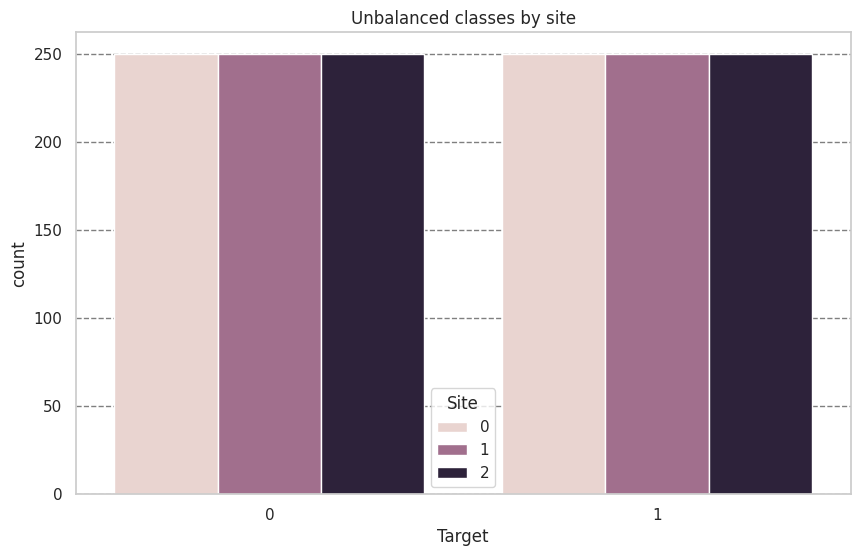

In [2]:
X_ref, y_ref, sites_ref = make_multisite_classification(
    n_samples=500,
    n_sites=1,
    n_features=2,
    site_effect_strength=0,
)

X_eos, y_eos, sites_eos = make_multisite_classification(
    n_sites=2,
    n_features=2,
    site_effect_strength=15,
)
sites_eos = sites_eos + 1  # Shift site labels to avoid overlap with reference site
X = np.vstack([X_ref, X_eos])
y = np.hstack([y_ref, y_eos])
sites = np.hstack([sites_ref, sites_eos])


df = pd.DataFrame({"Target": y, "Site": sites})

plt.figure(figsize=[10, 6])
plt.title("Unbalanced classes by site")
sns.countplot(df, x="Target", hue="Site")
plt.grid(axis="y", color="black", alpha=0.5, linestyle="--")

## Let's create a instance of the ICI harmonizer

In [3]:
harm = OptimalTransportDomainAdaptation()

X_train, X_val, y_train, y_val, sites_train, sites_val = train_test_split(X, y, sites, test_size=0.5, random_state=42)

harm.fit(X=X_train, sites=sites_train, y=y_train, ref_site=0)
X_harmonized = harm.transform(X=X_val)

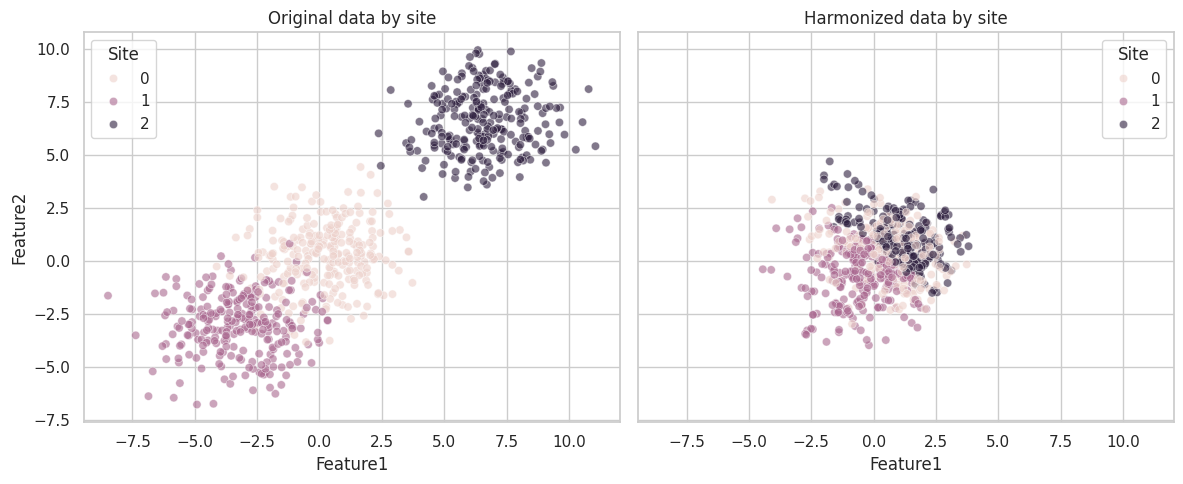

In [4]:
df_orig = pd.DataFrame(X_train, columns=["Feature1", "Feature2"])
df_orig["Site"] = sites_train
df_orig["Phase"] = "Original"

df_harm = pd.DataFrame(X_harmonized, columns=["Feature1", "Feature2"])
df_harm["Site"] = sites_val
df_harm["Phase"] = "Harmonized"

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sns.scatterplot(data=df_orig, x="Feature1", y="Feature2", hue="Site", alpha=0.6, ax=axes[0])
axes[0].set_title("Original data by site")
sns.scatterplot(data=df_harm, x="Feature1", y="Feature2", hue="Site", alpha=0.6, ax=axes[1])
axes[1].set_title("Harmonized data by site")
plt.tight_layout()

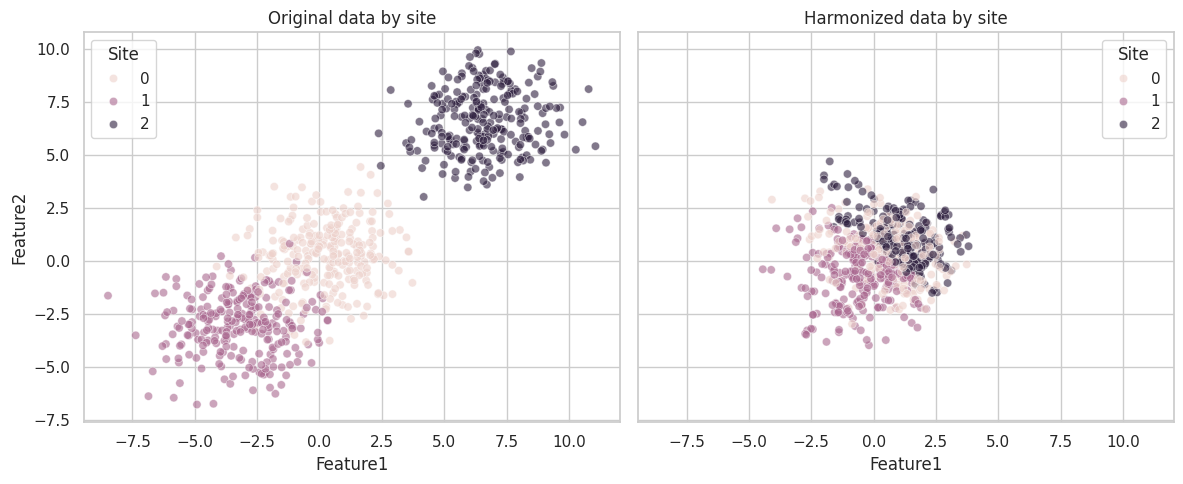

In [5]:
harm = OptimalTransportDomainAdaptation()

X_train, X_val, y_train, y_val, sites_train, sites_val = train_test_split(X, y, sites, test_size=0.5, random_state=42)

harm.fit(X=X_train, sites=sites_train, ref_site=0)
X_harmonized = harm.transform(X=X_val)
df_orig = pd.DataFrame(X_train, columns=["Feature1", "Feature2"])
df_orig["Site"] = sites_train
df_orig["Phase"] = "Original"

df_harm = pd.DataFrame(X_harmonized, columns=["Feature1", "Feature2"])
df_harm["Site"] = sites_val
df_harm["Phase"] = "Harmonized"

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sns.scatterplot(data=df_orig, x="Feature1", y="Feature2", hue="Site", alpha=0.6, ax=axes[0])
axes[0].set_title("Original data by site")
sns.scatterplot(data=df_harm, x="Feature1", y="Feature2", hue="Site", alpha=0.6, ax=axes[1])
axes[1].set_title("Harmonized data by site")
plt.tight_layout()

# Take home
Now the classes are balanced within each site, thus a ML model would not be able to pick a Effect of Site signal to give a fraudulently good performance